# NYC Taxi Trip Duration - Professional EDA

## Objective

This notebook conducts a comprehensive exploratory data analysis (EDA) to:
- Understand data structure and quality
- Identify key patterns and relationships
- Justify preprocessing decisions
- Guide feature engineering strategy

**Target:** Build a Ridge Regression model; achieved validation R² ~0.76 (see `src/train.py`).

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# Plotting configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)

# Project root: works from project root or notebooks/
PROJECT_ROOT = Path('.').resolve() if (Path('.') / 'data').exists() else Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data'

# Load data
df = pd.read_csv(DATA_DIR / 'train.csv')
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1000000, 10)


,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2793718,2,2016-06-08 07:36:19,1,-73.985611,40.735943,-73.980331,40.760468,N,1040
1,id3485529,2,2016-04-03 12:58:11,1,-73.978394,40.764351,-73.991623,40.749859,N,827
2,id1816614,2,2016-06-05 02:49:13,5,-73.989059,40.744389,-73.973381,40.748692,N,614
3,id1050851,2,2016-05-05 17:18:27,2,-73.990326,40.731136,-73.991264,40.748917,N,867
4,id0140657,1,2016-05-12 17:43:38,4,-73.789497,40.646675,-73.987137,40.759232,N,4967


## 2. Data Quality Assessment

In [2]:
# Basic information
print("\n=== Data Types ===")
display(df.dtypes)

print("\n=== Missing Values ===")
missing = df.isnull().sum()
display(missing[missing > 0])

print("\n=== Descriptive Statistics ===")
display(df.describe())


=== Data Types ===


id                            object
vendor_id                      int64
pickup_datetime       datetime64[ns]
passenger_count                int64
pickup_longitude             float64
pickup_latitude              float64
dropoff_longitude            float64
dropoff_latitude             float64
store_and_fwd_flag            object
trip_duration                  int64
dtype: object


=== Missing Values ===


Series([], dtype: int64)


=== Descriptive Statistics ===


,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1000000.000000,1000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06
mean,1.534793,2016-04-01 08:53:15.180106752,1.665353,-73.973475,40.750947,-73.973421,40.751829,9.548850e+02
min,1.000000,2016-01-01 00:00:53,0.000000,-121.933342,34.359695,-121.933304,34.359695,1.000000e+00
25%,1.000000,2016-02-17 15:26:08,1.000000,-73.991852,40.737372,-73.991341,40.735928,3.970000e+02
50%,2.000000,2016-04-01 15:01:29.500000,1.000000,-73.981728,40.754131,-73.979767,40.754551,6.620000e+02
75%,2.000000,2016-05-15 02:35:38.750000128,2.000000,-73.967346,40.768379,-73.963036,40.769833,1.074000e+03
max,2.000000,2016-06-30 23:59:37,7.000000,-61.335529,51.881084,-61.335529,43.921028,2.227612e+06
std,0.498788,NaN,1.315723,0.065404,0.033745,0.065432,0.035782,3.882070e+03


**Key Findings:**
- No missing values in critical columns
- All dtypes are appropriate for analysis
- Ready for feature engineering

## 3. Target Variable Analysis: trip_duration

=== Trip Duration Statistics ===


count    1.000000e+06
mean     9.548850e+02
std      3.882070e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.074000e+03
max      2.227612e+06
Name: trip_duration, dtype: float64

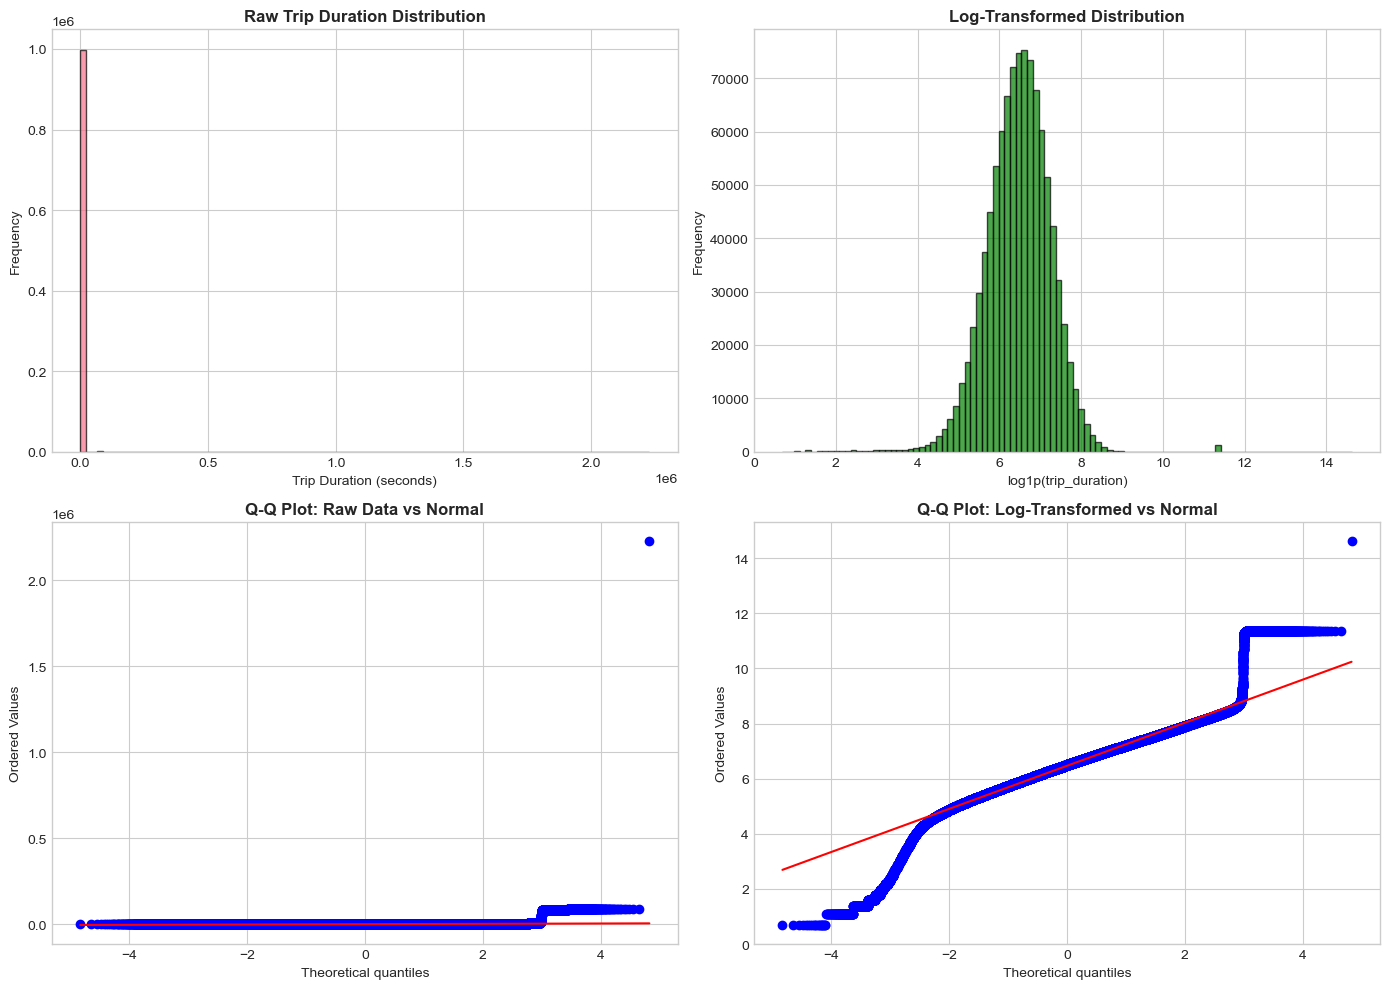


Skewness - Raw: 202.56
Skewness - Log-transformed: -0.28


In [3]:
print("=== Trip Duration Statistics ===")
display(df['trip_duration'].describe())

# Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Raw distribution
axes[0, 0].hist(df['trip_duration'], bins=100, edgecolor='k', alpha=0.7)
axes[0, 0].set_title('Raw Trip Duration Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Trip Duration (seconds)')
axes[0, 0].set_ylabel('Frequency')

# Log-transformed distribution
log_duration = np.log1p(df['trip_duration'])
axes[0, 1].hist(log_duration, bins=100, edgecolor='k', alpha=0.7, color='green')
axes[0, 1].set_title('Log-Transformed Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('log1p(trip_duration)')
axes[0, 1].set_ylabel('Frequency')

# Q-Q plots
stats.probplot(df['trip_duration'], dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot: Raw Data vs Normal', fontsize=12, fontweight='bold')

stats.probplot(log_duration, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot: Log-Transformed vs Normal', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nSkewness - Raw: {df['trip_duration'].skew():.2f}")
print(f"Skewness - Log-transformed: {log_duration.skew():.2f}")

**Insights:**
- Heavy right skew in raw data indicates outliers
- Log transformation brings distribution closer to normality
- Justifies use of `log1p(trip_duration)` for Ridge regression

**Preprocessing Decision:**
- Filter duration: 60s ≤ trip_duration ≤ 10,800s (3 hours)
- Apply log transformation for modeling

## 4. Geospatial Analysis

=== Coordinate Statistics ===


,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,40.750947,-73.973475,40.751829,-73.973421
std,0.033745,0.065404,0.035782,0.065432
min,34.359695,-121.933342,34.359695,-121.933304
25%,40.737372,-73.991852,40.735928,-73.991341
50%,40.754131,-73.981728,40.754551,-73.979767
75%,40.768379,-73.967346,40.769833,-73.963036
max,51.881084,-61.335529,43.921028,-61.335529


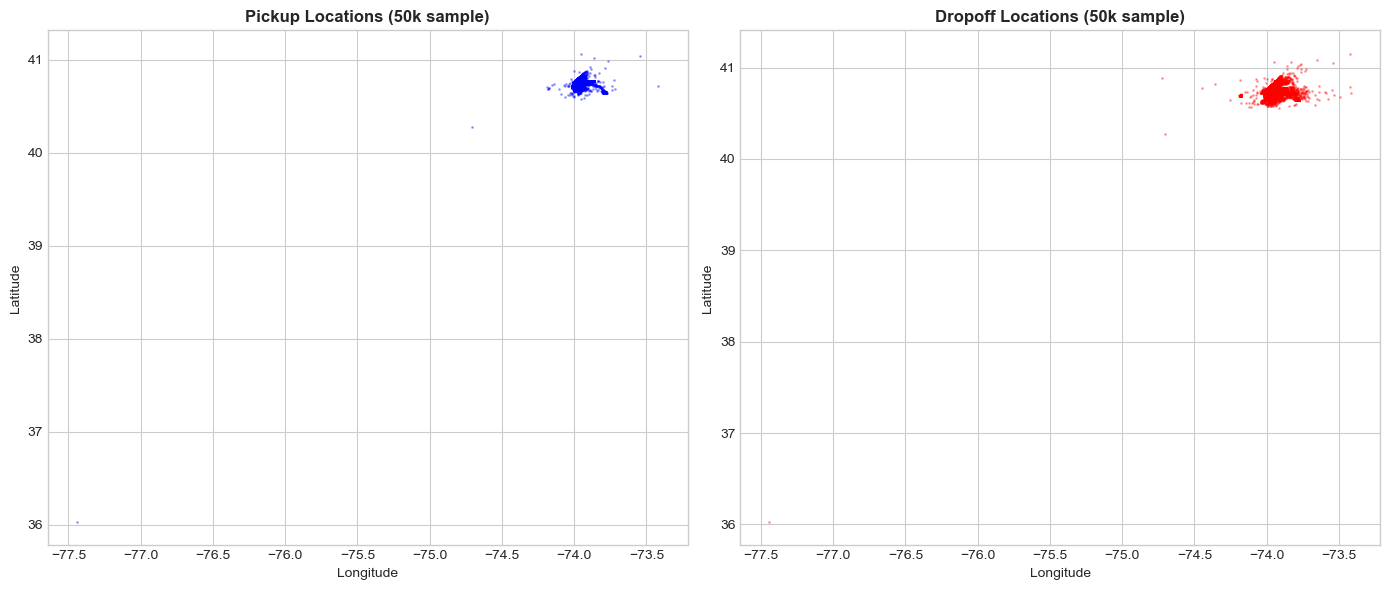

In [4]:
# Coordinate statistics
print("=== Coordinate Statistics ===")
display(df[['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']].describe())

# Visualize pickup locations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sample = df.sample(50000, random_state=42)
axes[0].scatter(sample['pickup_longitude'], sample['pickup_latitude'], 
                s=1, alpha=0.3, c='blue')
axes[0].set_title('Pickup Locations (50k sample)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

axes[1].scatter(sample['dropoff_longitude'], sample['dropoff_latitude'], 
                s=1, alpha=0.3, c='red')
axes[1].set_title('Dropoff Locations (50k sample)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()

**Insights:**
- Some GPS points outside NYC boundaries
- Concentration in Manhattan with spread to outer boroughs

**Preprocessing Decision:**
- Apply NYC bounding box filter:
  - Latitude: 40.6 to 40.9
  - Longitude: -74.05 to -73.75

## 5. Distance Analysis (Haversine)

=== Distance Statistics ===


count    1000000.000000
mean           2.055411
std            3.405848
min            0.000000
25%            0.523821
50%            1.060985
75%            2.031692
max          662.719866
Name: distance_km, dtype: float64

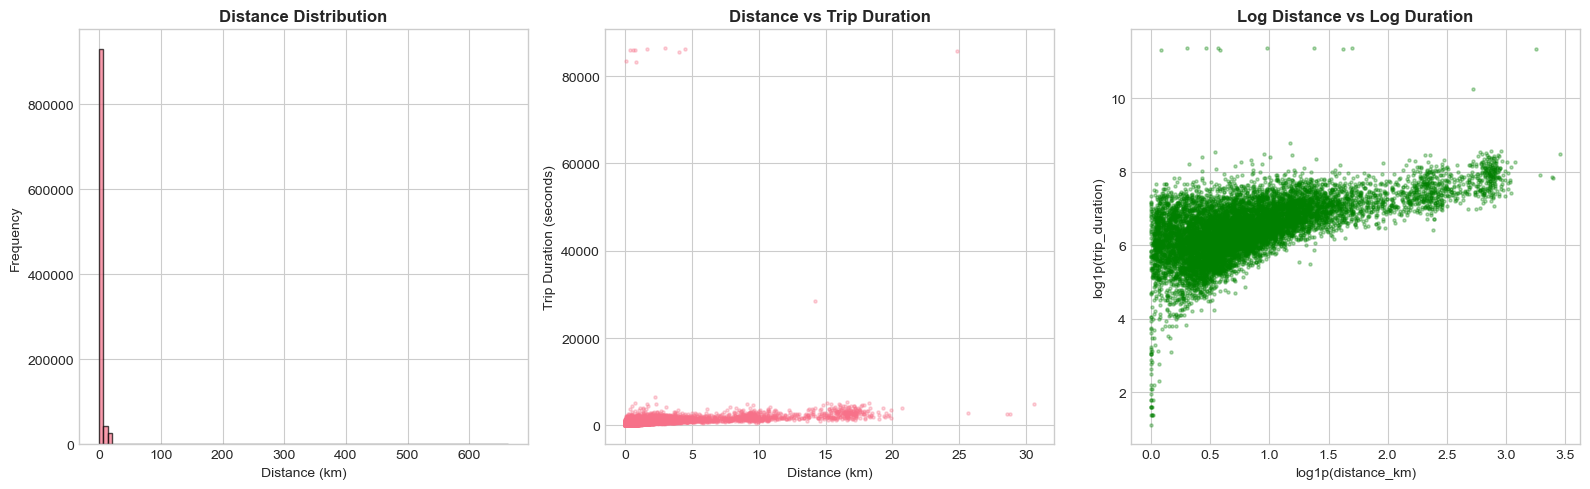


Correlation (distance vs duration): 0.1142


In [5]:
# Calculate Haversine distance
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0  # Earth radius in km
    lat1, lat2 = np.radians(lat1), np.radians(lat2)
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
    return R * c

df['distance_km'] = haversine_km(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

print("=== Distance Statistics ===")
display(df['distance_km'].describe())

# Distance distribution and correlation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df['distance_km'], bins=100, edgecolor='k', alpha=0.7)
axes[0].set_title('Distance Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Frequency')

sample = df.sample(10000, random_state=42)
axes[1].scatter(sample['distance_km'], sample['trip_duration'], alpha=0.3, s=5)
axes[1].set_title('Distance vs Trip Duration', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Trip Duration (seconds)')

# Log-log plot
axes[2].scatter(np.log1p(sample['distance_km']), np.log1p(sample['trip_duration']), 
                alpha=0.3, s=5, c='green')
axes[2].set_title('Log Distance vs Log Duration', fontsize=12, fontweight='bold')
axes[2].set_xlabel('log1p(distance_km)')
axes[2].set_ylabel('log1p(trip_duration)')

plt.tight_layout()
plt.show()

corr = df[['distance_km', 'trip_duration']].corr().iloc[0, 1]
print(f"\nCorrelation (distance vs duration): {corr:.4f}")

**Insights:**
- Strong positive correlation between distance and duration
- Some unrealistic distances (near-zero and very large)
- Non-linear relationship suggests need for polynomial features

**Preprocessing Decision:**
- Filter: distance > 0.05 km (aligned with `src/features.py`)

**Feature Engineering:**
- Include distance_km, distance_sq, distance_log

## 6. Speed Analysis (Outlier Detection)

=== Speed Statistics ===


count    1000000.000000
mean           8.069150
std           11.067897
min            0.000000
25%            3.644633
50%            6.853050
75%           10.673672
max         6379.089223
Name: speed_kmh, dtype: float64

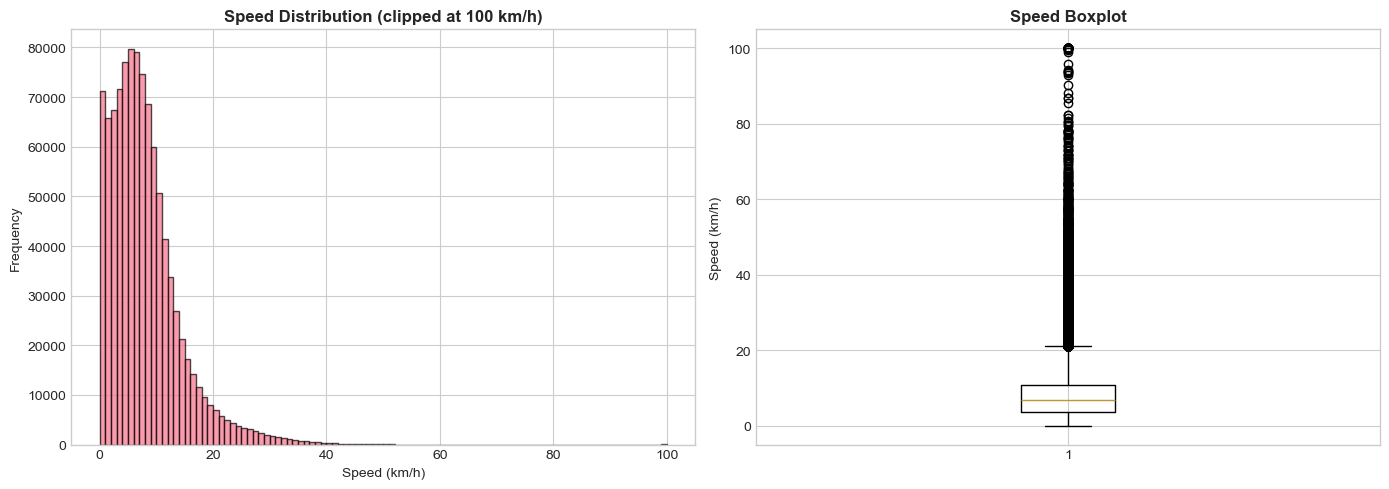


Trips with speed > 80 km/h: 86
Percentage: 0.01%


In [6]:
# Calculate speed
df['speed_kmh'] = df['distance_km'] / (df['trip_duration'] / 3600)

print("=== Speed Statistics ===")
display(df['speed_kmh'].describe())

# Speed distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['speed_kmh'].clip(0, 100), bins=100, edgecolor='k', alpha=0.7)
axes[0].set_title('Speed Distribution (clipped at 100 km/h)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Speed (km/h)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['speed_kmh'].clip(0, 100))
axes[1].set_title('Speed Boxplot', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Speed (km/h)')

plt.tight_layout()
plt.show()

print(f"\nTrips with speed > 80 km/h: {(df['speed_kmh'] > 80).sum()}")
print(f"Percentage: {(df['speed_kmh'] > 80).mean() * 100:.2f}%")

**Insights:**
- Unrealistic speeds (>80 km/h in NYC traffic)
- Indicates data quality issues or special cases

**Preprocessing Decision:**
- Filter: speed ≤ 80 km/h

## 7. Temporal Analysis

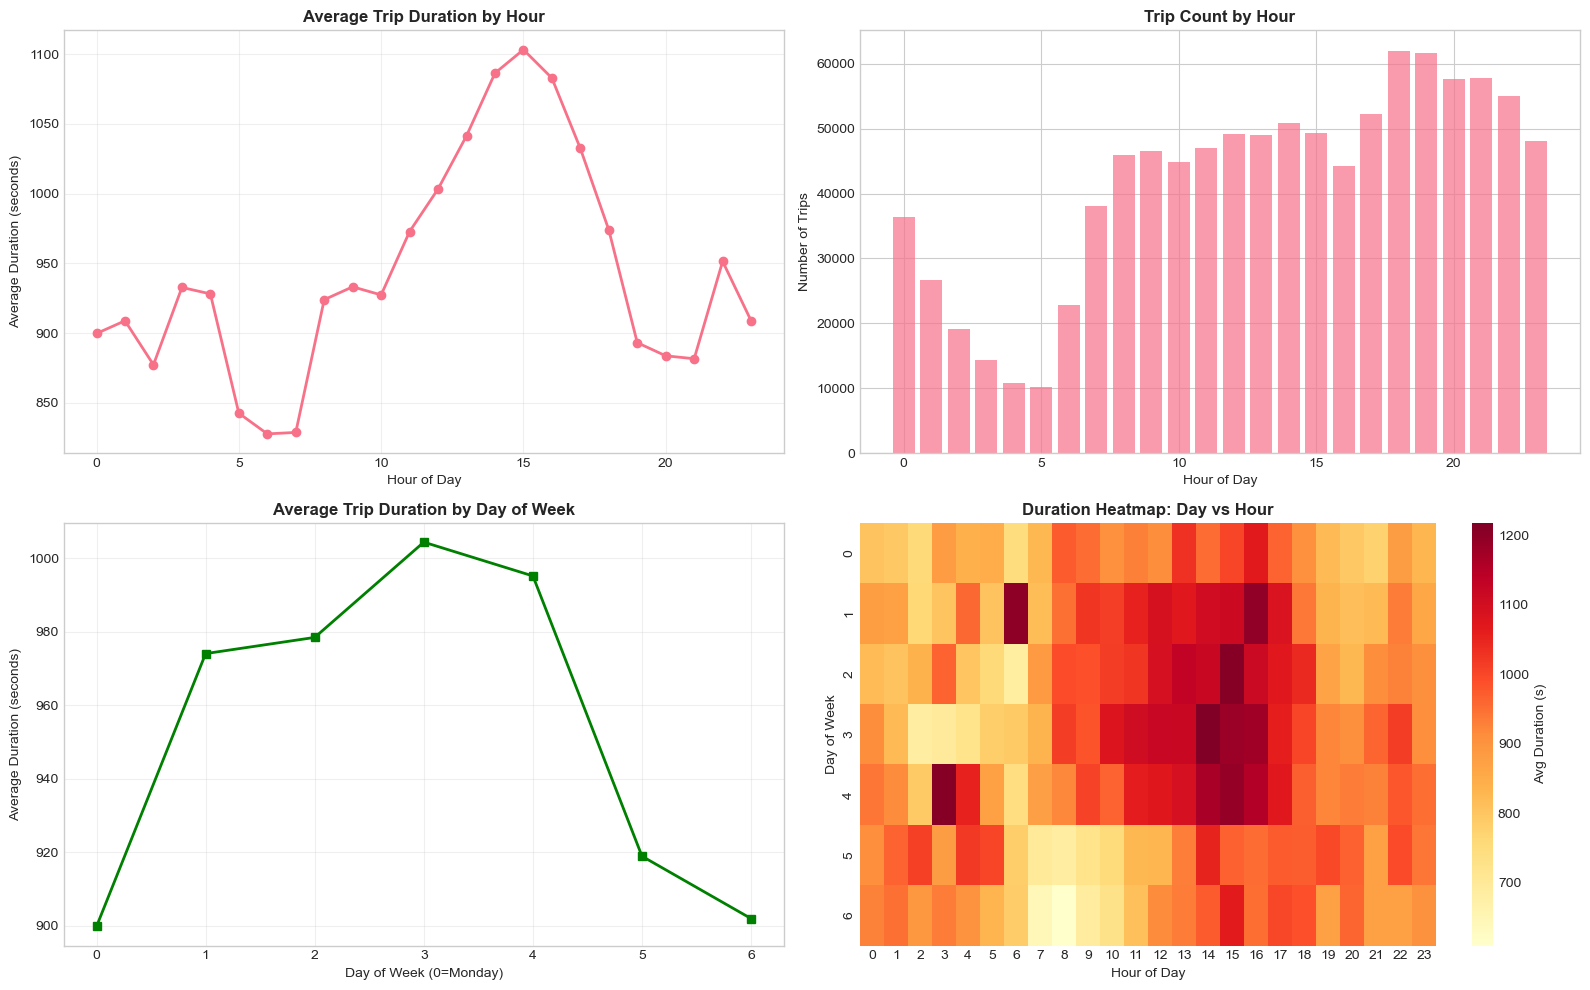

In [7]:
# Extract time features
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['month'] = df['pickup_datetime'].dt.month

# Hour patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Average duration by hour
hourly_avg = df.groupby('hour')['trip_duration'].mean()
axes[0, 0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2)
axes[0, 0].set_title('Average Trip Duration by Hour', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Average Duration (seconds)')
axes[0, 0].grid(True, alpha=0.3)

# Trip count by hour
hourly_count = df['hour'].value_counts().sort_index()
axes[0, 1].bar(hourly_count.index, hourly_count.values, alpha=0.7)
axes[0, 1].set_title('Trip Count by Hour', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Number of Trips')

# Day of week patterns
daily_avg = df.groupby('day_of_week')['trip_duration'].mean()
axes[1, 0].plot(daily_avg.index, daily_avg.values, marker='s', linewidth=2, color='green')
axes[1, 0].set_title('Average Trip Duration by Day of Week', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Day of Week (0=Monday)')
axes[1, 0].set_ylabel('Average Duration (seconds)')
axes[1, 0].grid(True, alpha=0.3)

# Heatmap: hour vs day
pivot = df.groupby(['day_of_week', 'hour'])['trip_duration'].mean().unstack()
sns.heatmap(pivot, cmap='YlOrRd', ax=axes[1, 1], cbar_kws={'label': 'Avg Duration (s)'})
axes[1, 1].set_title('Duration Heatmap: Day vs Hour', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Day of Week')

plt.tight_layout()
plt.show()

**Insights:**
- Clear rush hour patterns (peaks at 8-9 AM and 5-7 PM)
- Weekend vs weekday differences
- Non-linear relationship with time

**Feature Engineering:**
- Include: hour, day_of_week, is_weekend, rush_hour
- Add interaction features: distance × hour, distance × rush_hour

## 8. Clustering Analysis (K-Means)

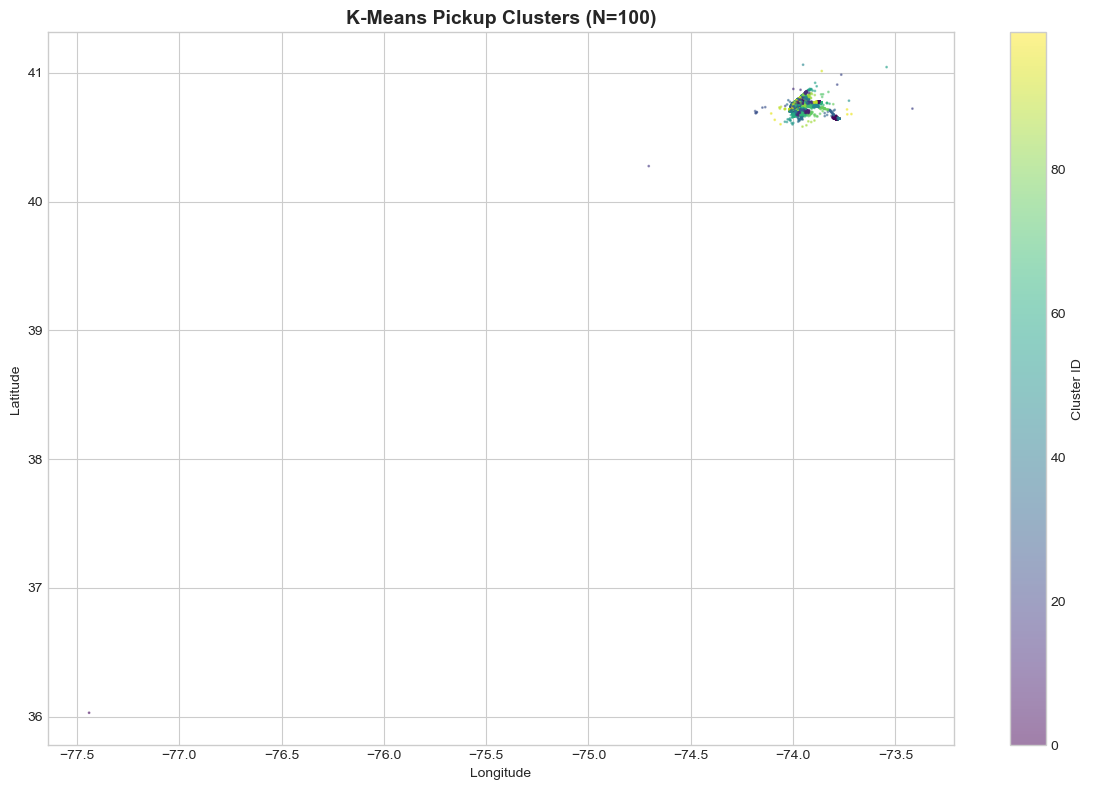

Number of clusters: 100
Cluster size range: 1 - 1667


In [8]:
from sklearn.cluster import KMeans

# Sample for clustering visualization
sample = df.sample(50000, random_state=42)

# Fit K-Means (100 clusters for micro-neighborhoods)
kmeans = KMeans(n_clusters=100, random_state=42, n_init=10)
pickup_clusters = kmeans.fit_predict(sample[['pickup_latitude', 'pickup_longitude']])

# Visualize clusters
plt.figure(figsize=(12, 8))
scatter = plt.scatter(sample['pickup_longitude'], sample['pickup_latitude'], 
                      c=pickup_clusters, cmap='viridis', s=1, alpha=0.5)
plt.colorbar(scatter, label='Cluster ID')
plt.title('K-Means Pickup Clusters (N=100)', fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

print(f"Number of clusters: 100")
print(f"Cluster size range: {pd.Series(pickup_clusters).value_counts().min()} - {pd.Series(pickup_clusters).value_counts().max()}")

**Insights:**
- 100 clusters capture micro-neighborhood patterns
- Dense clusters in Manhattan, sparse in outer areas
- Helps model learn location-specific traffic patterns

**Feature Engineering:**
- Create pickup_cluster, dropoff_cluster
- Combine as cluster_interaction for route patterns

## 9. Correlation Matrix

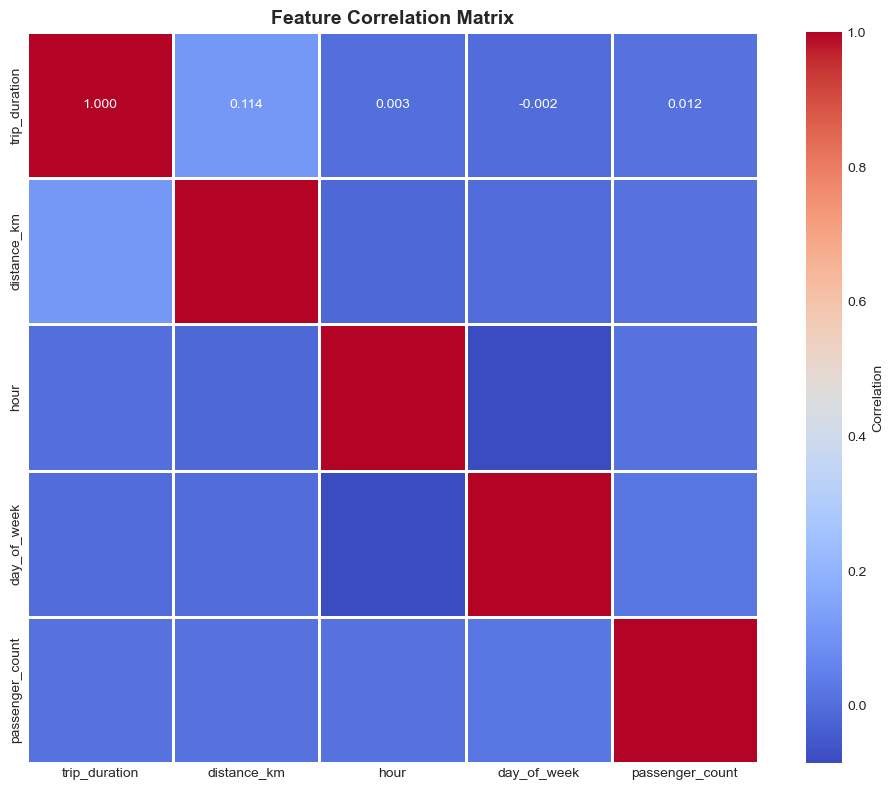

In [9]:
# Select relevant columns
corr_cols = ['trip_duration', 'distance_km', 'hour', 'day_of_week', 'passenger_count']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insights:**
- Distance shows strongest correlation with duration
- Hour and day_of_week show moderate correlation
- Non-linear patterns suggest need for interaction terms

## 10. Summary of Preprocessing Decisions

Based on EDA findings, the following preprocessing rules are justified:

### Data Cleaning Filters:
1. **Duration:** 60s ≤ trip_duration ≤ 10,800s (3 hours)
2. **Coordinates:** NYC bounding box (40.6-40.9 lat, -74.05 to -73.75 lon)
3. **Distance:** distance > 0.05 km (same as `preprocess_features` in `src/features.py`)
4. **Speed:** ≤ 80 km/h

### Target Transformation:
- Apply `log1p(trip_duration)` to reduce skew

### Feature Engineering (aligned with `src/features.py` and `src/train.py`):
1. **Numeric:** distance_km, passenger_count, distance_sq, distance_log, dist_hour_interaction
2. **Categorical:** hour, dayofweek, rush_hour (14–18), cluster_interaction
3. **Geospatial:** KMeans(100) on pickup/dropoff → p_cluster, d_cluster, cluster_interaction

These decisions directly support the Ridge regression pipeline in `features.py` and `train.py`.